# ☀️ Akıllı Şebeke Güneş Enerjisi Üretim Tahmini

**İsim:** Meliha Büşra Sağlam

**Ders:** Makine Öğrenmesi  

**Veri Seti:** Solar Power Generation Data — Kaggle (Hindistan Gerçek Santral Verisi)  



> *"Yenilenebilir enerji santrallerinin üretim belirsizliğini ortadan kaldırmak için 'akıllı şebeke tahmin modeli' geliştirdim. Gerçek santral verileriyle, hava durumuna göre yarın ne kadar elektrik üreteceğimizi tahmin ederek enerji arz güvenliğini sağlıyorum."*

---
## 1. 📌 Giriş ve Problem Tanımı

### 1.1 Problem Nedir? Neden Önemli?

Güneş enerjisi harika bir kaynak — ama **öngörülemez**. Bulut geçtiğinde üretim düşer, tam güneş varken zirve yapar. Bu dalgalanma enerji şebekeleri için ciddi bir sorun oluşturur:

| Durum | Sonuç |
|-------|-------|
| ☁️ Tahmin edilenden az üretim olursa | Şebeke talebi karşılayamaz → elektrik kesintisi |
| ☀️ Tahmin edilenden fazla üretim olursa | Fazla enerji şebekeyi bozar → ekipman hasarı |

Bu projenin amacı: **Hava koşullarına bakarak o güneş santralinin kaç kilowatt (kW) elektrik üreteceğini önceden tahmin etmek.**

---

### 1.2 Veri Seti Hakkında


| Özellik | Detay |
|---------|-------|
| **Kaynak** | Kaggle — *Solar Power Generation Data* (Hindistan gerçek santral verisi) |
| **Zaman Aralığı** | 34 günlük, 15 dakikada bir ölçüm |
| **Satır Sayısı** | ~68.000 satır |
| **Dosya Sayısı** | 2 ayrı CSV: üretim verisi + hava sensörü verisi |
| **Tahmin Edilecek** | `DC_POWER` — Doğru Akım Güç Üretimi (kW) |
| **Girdi Özellikleri** | Ortam sıcaklığı, modül sıcaklığı, güneş ışınımı, saat bilgisi |

📖 **DC Güç (DC Power):** Güneş panelinin ürettiği ham elektrik.  
📖 **Işınım (Irradiance/Irradiation):** Güneşten gelen enerji yoğunluğu.

---

### 1.3 Neden Makine Öğrenmesi?

Güneş üretimini etkileyen faktörler arasında **doğrusal olmayan (non-lineer) karmaşık ilişkiler** vardır:

- Sıcaklık arttıkça panel verimi önce artar, sonra **düşer** (tek yönlü bir ilişki değil)
- Işınım yüksek olsa bile panel çok ısınmışsa üretim azalır
- Saat 12:00 ile saat 07:00'ın aynı ışınımda farklı etkileri olabilir

Bu karmaşıklığı basit matematik formülleriyle yazmak mümkün değildir. Makine öğrenmesi modelleri ise bu ilişkileri en iyi şekilde çözümleriz.

In [27]:
!pip install xgboost optuna shap

import warnings
warnings.filterwarnings('ignore')

# Sayısal işlemler için
import numpy as np

# Tablo (DataFrame) işlemleri için
import pandas as pd

# Grafik çizimi için
import matplotlib.pyplot as plt
import seaborn as sns

# Süre ölçmek için (modellerin eğitim süresini ölçeceğiz)
import time

# Makine öğrenmesi araçları
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler       # Veriyi ölçeklendirme
from sklearn.pipeline import Pipeline                  # İşlem hattı
from sklearn.linear_model import LinearRegression      # Doğrusal Regresyon modeli
from sklearn.ensemble import RandomForestRegressor     # Rastgele Orman modeli
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error  # Başarı ölçütleri

# Güçlü tahmin algoritması
from xgboost import XGBRegressor

# Otomatik parametre bulucu
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # Optuna'nın çok fazla mesaj yazmasını engelle

# Model açıklayıcı
import shap

# Rastgelelik kontrolü: aynı kodu çalıştırınca hep aynı sonucu almak için
# 42 sayısı geleneksel olarak kullanılır ("Yaşamın, Evrenin ve Her Şeyin Cevabı")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('✅ Tüm kütüphaneler başarıyla yüklendi!')

✅ Tüm kütüphaneler başarıyla yüklendi!


---
## 3. 📥 Veri Yükleme

1. **Üretim Verisi** (`Plant_1_Generation_Data.csv`): Santralin her 15 dakikada ürettiği elektrik miktarı
2. **Sensör Verisi** (`Plant_1_Weather_Sensor_Data.csv`): Aynı anlarda ölçülen hava koşulları (sıcaklık, ışınım)


In [28]:
# ---- İki CSV dosyasını oku ve tabloya çevir ----
gen_df  = pd.read_csv('Plant_1_Generation_Data.csv')         # Üretim verisi
sens_df = pd.read_csv('Plant_1_Weather_Sensor_Data.csv')     # Hava sensörü verisi

print('📊 Dosya boyutları:')
print(f'  Üretim verisi  : {gen_df.shape[0]:,} satır, {gen_df.shape[1]} sütun')
print(f'  Sensör verisi  : {sens_df.shape[0]:,} satır, {sens_df.shape[1]} sütun')

print('\n--- Üretim Verisinin İlk 3 Satırı ---')
display(gen_df.head(3))

print('\n--- Sensör Verisinin İlk 3 Satırı ---')
display(sens_df.head(3))

📊 Dosya boyutları:
  Üretim verisi  : 68,778 satır, 7 sütun
  Sensör verisi  : 3,182 satır, 6 sütun

--- Üretim Verisinin İlk 3 Satırı ---


,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0



--- Sensör Verisinin İlk 3 Satırı ---


,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0


In [29]:
# Her iki dosyada tarih formatı farklı yazılmış — önce standart hale getiriyoruz
gen_df['DATE_TIME']  = pd.to_datetime(gen_df['DATE_TIME'],  format='%d-%m-%Y %H:%M')
sens_df['DATE_TIME'] = pd.to_datetime(sens_df['DATE_TIME'], format='%Y-%m-%d %H:%M:%S')

# 📖 merge (birleştirme): İki tabloyu ortak sütun üzerinden yan yana getirme
# how='inner' → sadece her iki tabloda da eşleşen satırları al
df = pd.merge(gen_df, sens_df, on='DATE_TIME', how='inner')

print('✅ Tablolar başarıyla birleştirildi!')
print(f'Birleştirilmiş veri: {df.shape[0]:,} satır, {df.shape[1]} sütun')
print('\n--- Birleştirilmiş Tablonun İlk 3 Satırı ---')
display(df.head(3))

✅ Tablolar başarıyla birleştirildi!
Birleştirilmiş veri: 68,774 satır, 12 sütun

--- Birleştirilmiş Tablonun İlk 3 Satırı ---


,DATE_TIME,PLANT_ID_x,SOURCE_KEY_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,PLANT_ID_y,SOURCE_KEY_y,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0



Model bu ilişkiyi öğrenecek:

```
Saat 10:15 → Işınım: 450 W/m², Sıcaklık: 28°C → DC Güç: 1.250 kW
Saat 12:00 → Işınım: 820 W/m², Sıcaklık: 35°C → DC Güç: 2.100 kW
```

---
## 4. 🔍 Keşifsel Veri Analizi (EDA)

📖 **Keşifsel Veri Analizi (EDA — Exploratory Data Analysis):** Model kurmadan önce veriyi tanımak için yapılan ön inceleme. "Veride ne var, nasıl dağılmış, eksik var mı, ne kadar güvenilir?" sorularını cevaplanır.

### Neden yapıyoruz?

- Verideki **eksik değerleri** buluruz
- **Aykırı değerleri (outlier)** tespit ederiz
- Hangi özelliklerin hedef ile **ilişkili** olduğunu görürüz
- Ön işleme stratejimizi belirleriz

---
### 4.1 Temel İstatistikler ve Eksik Değer Analizi

In [30]:
from sklearn.feature_selection import VarianceThreshold
import pandas as pd

# 1. Sayısal sütunları al
df_numeric = df.select_dtypes(include=['number'])

# 2. ÖNCE: Tüm sayısal sütunların varyans tablosu
print('=== ÖNCE: TÜM SAYISAL SÜTUNLAR ===')
variance_df = pd.DataFrame({
    'Varyans': df_numeric.var().round(6),
    'Benzersiz Değer': df_numeric.nunique(),
    'Durum': ['🗑️ SABİT (silinecek)' if v == 0 else '✅ Değişken' for v in df_numeric.var()]
})
display(variance_df)

# 3. Varyansı sıfır olan sütunları tespit et
selector = VarianceThreshold(threshold=0)
selector.fit(df_numeric)

removed_cols = df_numeric.columns[~selector.get_support()].tolist()
kept_cols    = df_numeric.columns[selector.get_support()].tolist()

print(f'\n🗑️  Kaldırılan sabit sütunlar : {removed_cols}')

# 4. Temizlenmiş DataFrame
df_filtered = df[kept_cols]
print(f'\n📊 Sonuç: {df.shape[1]} sütun → {df_filtered.shape[1]} sütun ({len(removed_cols)} sütun kaldırıldı)')

# 5. SONRA: df_filtered'in ilk satırlarını göster
print('\n=== SONRA: TEMİZLENMİŞ VERİ SETİ (ilk 5 satır) ===')
display(df_filtered.head())

# 6. SONRA: Kalan sütunların varyans özeti
print('\n=== SONRA: KALAN SÜTUNLARIN VARYANS ÖZETİ ===')
display(pd.DataFrame({
    'Varyans': df_filtered.var().round(6),
    'Benzersiz Değer': df_filtered.nunique()
}))
# 7. EKSİK DEĞER ANALİZİ 
print('\n=== EKSİK DEĞER ANALİZİ ===')
eksik_df = pd.DataFrame({
    'Eksik Değer Sayısı': df.isnull().sum(),
    'Eksik Oran (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
eksik_df = eksik_df[eksik_df['Eksik Değer Sayısı'] > 0]
if len(eksik_df) == 0:
    print('✅ Veri setinde eksik değer bulunmamaktadır.')
else:
    display(eksik_df)
    print('\n💡 Eksik Değer Stratejisi: Eksik değer içeren satırlar silinecek veya medyan ile doldurulacaktır.')

# 8. TEMEL İSTATİSTİKLER 
print('\n=== TEMEL İSTATİSTİKLER (Sayısal Sütunlar) ===')
display(df.describe().round(2))


=== ÖNCE: TÜM SAYISAL SÜTUNLAR ===


,Varyans,Benzersiz Değer,Durum
PLANT_ID_x,0.000000e+00,1,🗑️ SABİT (silinecek)
DC_POWER,1.629286e+07,32906,✅ Değişken
AC_POWER,1.555473e+05,32683,✅ Değişken
DAILY_YIELD,9.892413e+06,29899,✅ Değişken
TOTAL_YIELD,1.732813e+11,37263,✅ Değişken
PLANT_ID_y,0.000000e+00,1,🗑️ SABİT (silinecek)
AMBIENT_TEMPERATURE,1.129834e+01,3157,✅ Değişken
MODULE_TEMPERATURE,1.514938e+02,3157,✅ Değişken
IRRADIATION,9.117200e-02,1755,✅ Değişken



🗑️  Kaldırılan sabit sütunlar : ['PLANT_ID_x', 'PLANT_ID_y']

📊 Sonuç: 12 sütun → 7 sütun (2 sütun kaldırıldı)

=== SONRA: TEMİZLENMİŞ VERİ SETİ (ilk 5 satır) ===


,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,0.0,0.0,0.0,6259559.0,25.184316,22.857507,0.0
1,0.0,0.0,0.0,6183645.0,25.184316,22.857507,0.0
2,0.0,0.0,0.0,6987759.0,25.184316,22.857507,0.0
3,0.0,0.0,0.0,7602960.0,25.184316,22.857507,0.0
4,0.0,0.0,0.0,7158964.0,25.184316,22.857507,0.0



=== SONRA: KALAN SÜTUNLARIN VARYANS ÖZETİ ===


,Varyans,Benzersiz Değer
DC_POWER,1.629286e+07,32906
AC_POWER,1.555473e+05,32683
DAILY_YIELD,9.892413e+06,29899
TOTAL_YIELD,1.732813e+11,37263
AMBIENT_TEMPERATURE,1.129834e+01,3157
MODULE_TEMPERATURE,1.514938e+02,3157
IRRADIATION,9.117200e-02,1755



=== EKSİK DEĞER ANALİZİ ===
✅ Veri setinde eksik değer bulunmamaktadır.

=== TEMEL İSTATİSTİKLER (Sayısal Sütunlar) ===


,DATE_TIME,PLANT_ID_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,PLANT_ID_y,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
count,68774,68774.0,68774.00,68774.00,68774.00,68774.00,68774.0,68774.00,68774.00,68774.00
mean,2020-06-01 08:02:38.161514240,4135001.0,3147.18,307.78,3295.83,6978727.51,4135001.0,25.56,31.24,0.23
min,2020-05-15 00:00:00,4135001.0,0.00,0.00,0.00,6183645.00,4135001.0,20.40,18.14,0.00
25%,2020-05-24 00:33:45,4135001.0,0.00,0.00,0.00,6512006.83,4135001.0,22.72,21.12,0.00
50%,2020-06-01 14:15:00,4135001.0,428.57,41.45,2658.47,7146685.00,4135001.0,24.67,24.82,0.03
75%,2020-06-09 20:00:00,4135001.0,6365.47,623.56,6274.00,7268751.40,4135001.0,27.96,41.69,0.45
max,2020-06-17 23:45:00,4135001.0,14471.12,1410.95,9163.00,7846821.00,4135001.0,35.25,65.55,1.22
std,NaN,0.0,4036.44,394.39,3145.22,416270.72,0.0,3.36,12.31,0.30


Veri seti incelendiğinde, PLANT_ID sütununun tüm gözlemler için aynı değeri (4133001) aldığı saptanmıştır. İstatistiksel olarak varyansı sıfır olan bu tür değişkenler, makine öğrenmesi modellerine herhangi bir ayırt edici bilgi sağlamaz ve model karmaşıklığını gereksiz yere artırır.

---
### 4.2 Hedef Değişkenin Dağılımı

📖 **Hedef Değişken (Target Variable):** Tahmin etmeye çalıştığımız sütun. Bizim için bu `DC_POWER`.

📖 **Histogram:** Değerlerin hangi aralıklarda kaç kez göründüğünü gösteren çubuk grafik.

📖 **Boxplot (Kutu Grafiği):** Minimum, maksimum, medyan ve çeyrekleri tek grafikte gösteren özet görsel.

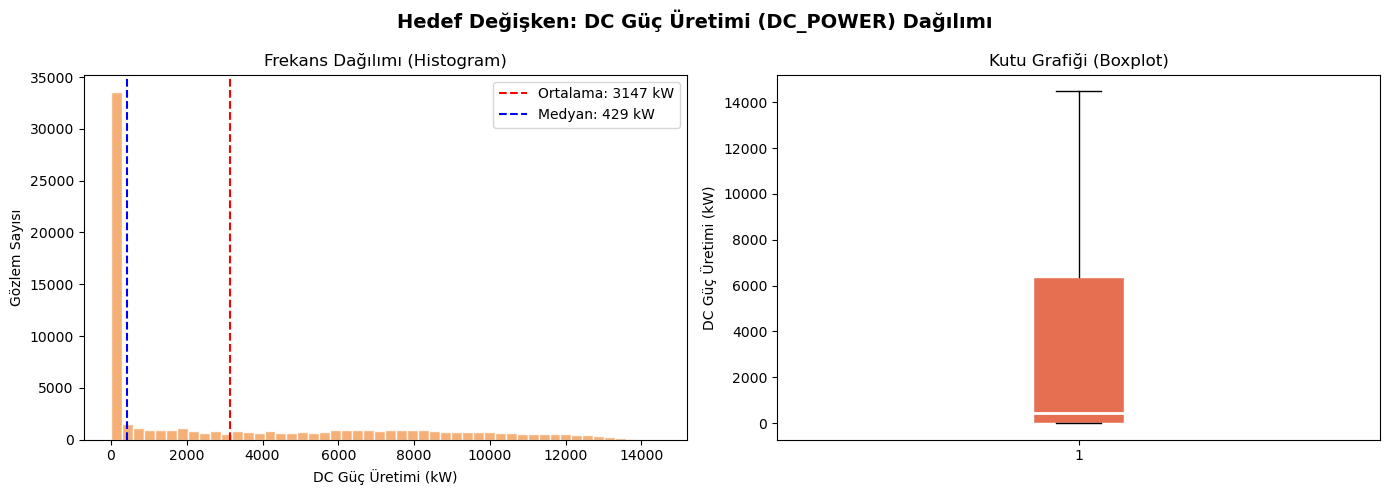

📊 DC Güç Üretimi Özet İstatistikleri:
  Ortalama  : 3147.18 kW
  Medyan    : 428.57 kW
  Std Sapma : 4036.44 kW  ← değerler bu kadar dağınık
  Minimum   : 0.00 kW  ← gece saatleri sıfır
  Maksimum  : 14471.12 kW  ← tam güneş anı


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Hedef Değişken: DC Güç Üretimi (DC_POWER) Dağılımı', fontsize=14, fontweight='bold')

# Sol grafik: Histogram — değerlerin frekans dağılımı
axes[0].hist(df['DC_POWER'], bins=50, color='#F4A261', edgecolor='white', alpha=0.85)
axes[0].set_title('Frekans Dağılımı (Histogram)')
axes[0].set_xlabel('DC Güç Üretimi (kW)')
axes[0].set_ylabel('Gözlem Sayısı')
axes[0].axvline(df['DC_POWER'].mean(), color='red', linestyle='--', label=f"Ortalama: {df['DC_POWER'].mean():.0f} kW")
axes[0].axvline(df['DC_POWER'].median(), color='blue', linestyle='--', label=f"Medyan: {df['DC_POWER'].median():.0f} kW")
axes[0].legend()

# Sağ grafik: Boxplot — özet istatistikleri görsel olarak
axes[1].boxplot(df['DC_POWER'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#E76F51', color='white'),
                medianprops=dict(color='white', linewidth=2))
axes[1].set_title('Kutu Grafiği (Boxplot)')
axes[1].set_ylabel('DC Güç Üretimi (kW)')

plt.tight_layout()
plt.show()

print('📊 DC Güç Üretimi Özet İstatistikleri:')
print(f'  Ortalama  : {df["DC_POWER"].mean():.2f} kW')
print(f'  Medyan    : {df["DC_POWER"].median():.2f} kW')
print(f'  Std Sapma : {df["DC_POWER"].std():.2f} kW  ← değerler bu kadar dağınık')
print(f'  Minimum   : {df["DC_POWER"].min():.2f} kW  ← gece saatleri sıfır')
print(f'  Maksimum  : {df["DC_POWER"].max():.2f} kW  ← tam güneş anı')

Histogram (Solda): Verilerin büyük çoğunluğunun sıfıra yakın yığıldığını göstererek, geceleri üretimin durmasından kaynaklanan yüksek frekanslı bir sağa çarpık (pozitif çarpık) dağılım sergilemektedir.

Kutu Grafiği (Sağda): Üretim değerlerinin yayılımını ve uç noktalarını özetlemekte; medyanın alt kısma çok yakın olması, düşük üretim verilerinin baskınlığını ve yüksek güneşli saatlerin ise üst kısımdaki geniş varyasyonla temsil edildiğini doğrulamaktadır.
DC_POWER değerlerinin önemli bir kısmı 0 (gece). Bu nedenle sadece **gündüz saatlerini** alarak model kurarsak daha temiz sonuç elde ederiz.

---
### 4.3 Korelasyon Matrisi

📖 **Korelasyon (Correlation):** İki değişkenin birlikte ne kadar hareket ettiğini ölçen sayı. -1 ile +1 arasında değer alır:

| Değer | Anlamı |
|-------|--------|
| +1.0 | Biri artınca diğeri de tam orantılı artar |
| +0.7 | Güçlü pozitif ilişki |
| 0.0 | Hiç ilişki yok |
| -0.7 | Biri artınca diğeri azalır (güçlü negatif) |
| -1.0 | Tam ters ilişki |

📖 **Isı Haritası (Heatmap):** Sayısal değerleri renklerle gösteren tablo. Koyu yeşil = yüksek pozitif korelasyon.

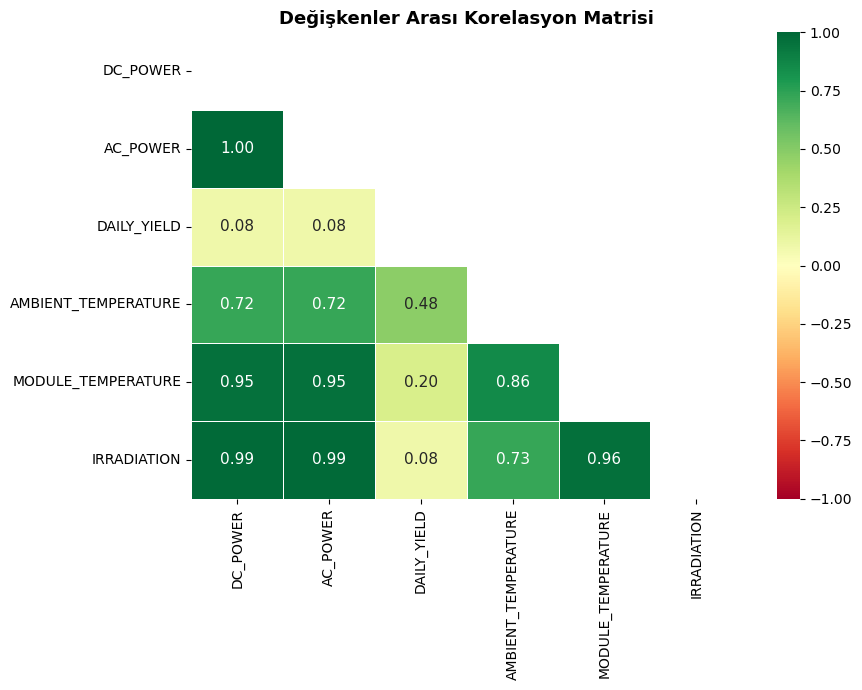


🔎 DC_POWER ile en yüksek korelasyona sahip değişkenler:
  AC_POWER                  : +1.000  ███████████████████
  IRRADIATION               : +0.989  ███████████████████
  MODULE_TEMPERATURE        : +0.955  ███████████████████
  AMBIENT_TEMPERATURE       : +0.725  ██████████████
  DAILY_YIELD               : +0.082  █


In [32]:
# Sayısal sütunları seç (korelasyon sadece sayılar için hesaplanır)
num_cols = ['DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'AMBIENT_TEMPERATURE',
            'MODULE_TEMPERATURE', 'IRRADIATION']
# Sadece mevcut sütunları al (bazı versiyonlarda farklı isim olabilir)
num_cols = [c for c in num_cols if c in df.columns]

# Korelasyon matrisini hesapla
corr = df[num_cols].corr()

plt.figure(figsize=(9, 7))

# Üst üçgeni gizle 
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr,
            annot=True,      # Her hücreye sayıyı yaz
            fmt='.2f',       # 2 ondalık basamak
            cmap='RdYlGn',   # Kırmızı→Sarı→Yeşil renk geçişi
            mask=mask,
            vmin=-1, vmax=1,
            linewidths=0.5,
            annot_kws={'size': 11})

plt.title('Değişkenler Arası Korelasyon Matrisi', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n🔎 DC_POWER ile en yüksek korelasyona sahip değişkenler:')
dc_corr = corr['DC_POWER'].drop('DC_POWER').sort_values(ascending=False)
for col, val in dc_corr.items():
    bar = '█' * int(abs(val) * 20)
    print(f'  {col:<25} : {val:+.3f}  {bar}')


**Beklenen bulgular:**
- `IRRADIATION` ↔ `DC_POWER` → çok yüksek pozitif korelasyon (≈ 0.97) → **Işınım, güneş üretiminin ana belirleyicisi**
- `MODULE_TEMPERATURE` ↔ `DC_POWER` → pozitif ama ışınımdan daha düşük → **Sıcaklık da etkili ama ikincil**
- `AC_POWER` ↔ `DC_POWER` → neredeyse 1.0 → **AC ve DC birbirine dönüştürülüyor, çok benzer**

---
### 4.4 Anlamlı Görselleştirmeler

Üç farklı grafik tipiyle veri ilişkilerini görselleştiriyoruz:

1. **Dağılım Grafiği (Scatter Plot):** Işınım ile üretim arasındaki ilişki
2. **Dağılım Grafiği (Scatter Plot):** Modül sıcaklığı ile üretim ilişkisi
3. **Kutu Grafiği (Boxplot):** Saate göre üretim dağılımı

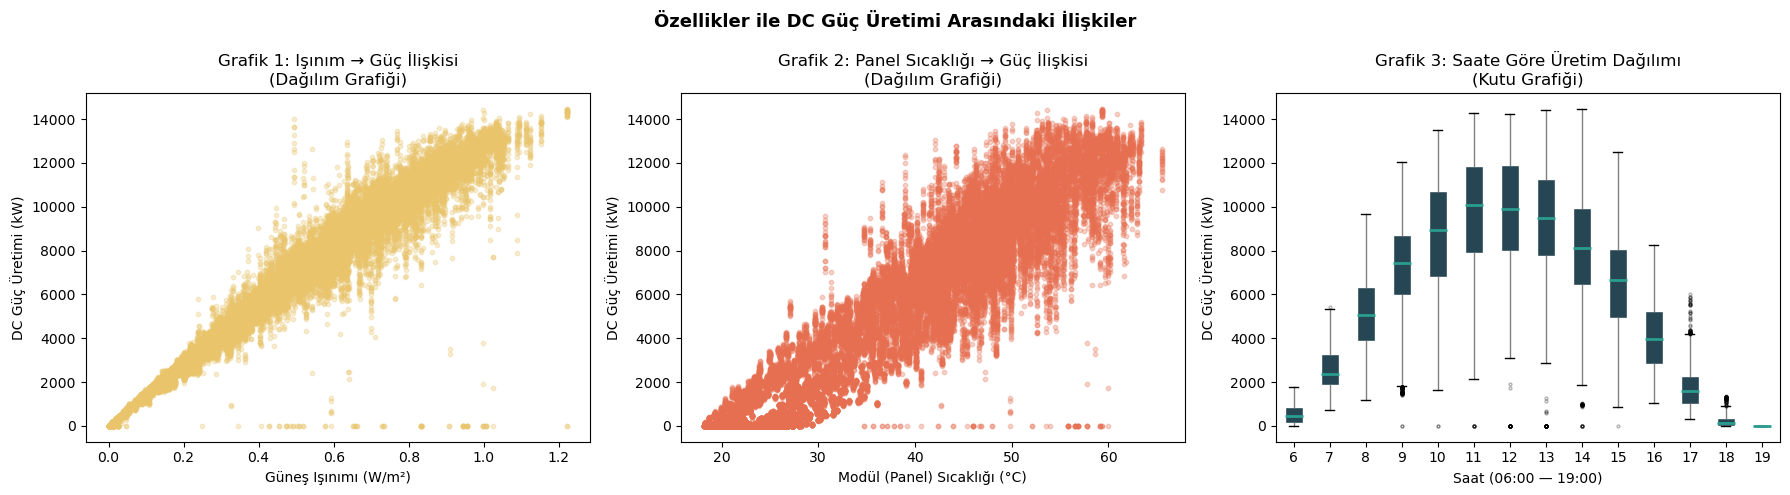

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Özellikler ile DC Güç Üretimi Arasındaki İlişkiler', fontsize=13, fontweight='bold')

# --- Grafik 1: Işınım → DC Güç (Dağılım Grafiği) ---
axes[0].scatter(df['IRRADIATION'], df['DC_POWER'],
                alpha=0.3,     # Şeffaflık: noktalar üst üste gelince fark edilebilsin
                color='#E9C46A',
                s=10)          # Nokta boyutu
axes[0].set_xlabel('Güneş Işınımı (W/m²)')
axes[0].set_ylabel('DC Güç Üretimi (kW)')
axes[0].set_title('Grafik 1: Işınım → Güç İlişkisi\n(Dağılım Grafiği)')

# --- Grafik 2: Modül Sıcaklığı → DC Güç ---
axes[1].scatter(df['MODULE_TEMPERATURE'], df['DC_POWER'],
                alpha=0.3, color='#E76F51', s=10)
axes[1].set_xlabel('Modül (Panel) Sıcaklığı (°C)')
axes[1].set_ylabel('DC Güç Üretimi (kW)')
axes[1].set_title('Grafik 2: Panel Sıcaklığı → Güç İlişkisi\n(Dağılım Grafiği)')

# --- Grafik 3: Saatlik Üretim Dağılımı ---
if 'DATE_TIME' in df.columns:
    df['HOUR'] = df['DATE_TIME'].dt.hour
    # Her saat için DC_POWER değerlerini grupla
    hourly = [df[df['HOUR'] == h]['DC_POWER'].values for h in range(6, 20)]
    axes[2].boxplot(hourly, labels=range(6, 20), patch_artist=True,
                    boxprops=dict(facecolor='#264653', color='white'),
                    medianprops=dict(color='#2A9D8F', linewidth=2),
                    whiskerprops=dict(color='gray'),
                    flierprops=dict(marker='o', markersize=2, alpha=0.3))
    axes[2].set_xlabel('Saat (06:00 — 19:00)')
    axes[2].set_ylabel('DC Güç Üretimi (kW)')
    axes[2].set_title('Grafik 3: Saate Göre Üretim Dağılımı\n(Kutu Grafiği)')

plt.tight_layout()
plt.show()


### 4.5 EDA Sonuç Özeti 

 | Bulgu | Anlam | Yapacağımız |
|-------|-------|-------------|
| `IRRADIATION` en güçlü öngörücü | Işınım bilgisi olmadan iyi tahmin imkânsız | Model girişinde muhakkak kullanacağız |
| Gece saatlerinde üretim = 0 | Gece verisi modeli karıştırır | Sadece gündüz verisiyle model kuracağız |
| Sıcaklık-güç ilişkisi doğrusal değil | Basit formülle modellenemez | XGBoost ve Random Forest bu eğriliği öğrenir |


---
## 5. 🛠️ Veri Ön İşleme

Varyansı sıfır olan ve bilgi taşımayan sabit değişken silinmiştir.  

### Özellik Mühendisliği 

📖 **Özellik Mühendisliği (Feature Engineering):** Mevcut sütunlardan yeni, daha anlamlı sütunlar türetme sanatı. Model bu yeni özellikleri kullanarak daha iyi öğrenir.

Türeteceğimiz yeni özellikler:

| Yeni Özellik | Formül | Anlam |
|--------------|--------|-------|
| `HOUR` | Tarih/saatten saat bilgisi | Günün hangi saatinde olduğumuz |
| `MONTH` | Tarih/saatten ay bilgisi | Mevsimsel etki |
| `IS_DAYTIME` | Saat 6-18 arası mı? | Gündüz/gece bayrağı |
| `IRRAD_X_TEMP` | Işınım × Modül Sıcaklığı | Etkileşim terimi: ikisinin birlikte etkisi |
| `PANEL_EFF_INDEX` | Işınım ÷ (Modül Sıcaklığı + 1) | Yüksek sıcaklıkta verim düşüşünü modelliyor |

In [34]:
# Zaman damgasından saat ve ay bilgisi çıkar
df['HOUR']  = df['DATE_TIME'].dt.hour
df['MONTH'] = df['DATE_TIME'].dt.month

# Gündüz bayrağı: saat 6-18 arası mı? → 1 (evet) veya 0 (hayır)
df['IS_DAYTIME'] = ((df['HOUR'] >= 6) & (df['HOUR'] <= 18)).astype(int)

# Etkileşim terimi: ışınım × modül sıcaklığı
# Açıklama: sadece ışınım değil, sıcaklıkla birlikte etkisi önemli
df['IRRAD_X_TEMP'] = df['IRRADIATION'] * df['MODULE_TEMPERATURE']

# Panel verim indeksi: sıcaklık arttıkça payda büyür, bölüm küçülür → verim düşüşünü modelliyor
df['PANEL_EFF_INDEX'] = df['IRRADIATION'] / (df['MODULE_TEMPERATURE'] + 1)

print('✅ Özellik mühendisliği tamamlandı!')
print(f'Toplam sütun sayısı: {df.shape[1]} (önceki + 5 yeni özellik)')
print('\n🆕 Yeni özellikler:')
yeni_ozellikler = ['HOUR', 'MONTH', 'IS_DAYTIME', 'IRRAD_X_TEMP', 'PANEL_EFF_INDEX']
display(df[yeni_ozellikler].head(5))

✅ Özellik mühendisliği tamamlandı!
Toplam sütun sayısı: 17 (önceki + 5 yeni özellik)

🆕 Yeni özellikler:


,HOUR,MONTH,IS_DAYTIME,IRRAD_X_TEMP,PANEL_EFF_INDEX
0,0,5,0,0.0,0.0
1,0,5,0,0.0,0.0
2,0,5,0,0.0,0.0
3,0,5,0,0.0,0.0
4,0,5,0,0.0,0.0


---
### 5.3 Girdi Özellikleri ve Hedef Değişken Seçimi

📖 **Girdi Özellikleri (Features / X):** Modele "bunlara bakarak tahmin yap" dediğimiz sütunlar.

📖 **Hedef Değişken (Target / y):** Tahmin etmek istediğimiz sütun. Modelin "doğru cevabı" bunlar.

Ayrıca gece saatlerini (IS_DAYTIME = 0) çıkartıyoruz. Neden?
- Gece üretimi her zaman sıfır
- Gece veri noktaları modeli "kolayca sıfır tahmin et" düşüncesine iter
- Gündüz tahminlerini iyileştirmek istiyoruz

In [35]:
FEATURE_COLS = [
    'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION',
    'HOUR', 'MONTH', 'IS_DAYTIME',
    'IRRAD_X_TEMP', 'PANEL_EFF_INDEX'
]
TARGET_COL = 'DC_POWER'

# Yalnızca gündüz saatlerini al (gece=0 üretimi modeli bozar)
df_day = df[df['IS_DAYTIME'] == 1].copy()

X = df_day[FEATURE_COLS]
y = df_day[TARGET_COL]

print(f'Gündüz örnek sayısı : {len(X)}')
print(f'Özellik sayısı      : {X.shape[1]}')

Gündüz örnek sayısı : 37927
Özellik sayısı      : 8


---
### 5.4 Veri Bölme: Eğitim / Doğrulama / Test (%70 / %15 / %15)

📖 **Eğitim Seti (Training Set):** Modelin "ders çalıştığı" veri. Model bu verideki kalıpları öğrenir.

📖 **Doğrulama Seti (Validation Set):** Modelin hiperparametreleri ayarlanırken kullanılan kontrol verisi.

📖 **Test Seti (Test Set):** Model tüm eğitim ve ayar sürecinde **hiç görmediği** veri. Gerçek başarıyı buradan ölçeriz.


In [36]:
# IS_DAYTIME sütunu oluştur
df['IS_DAYTIME'] = (df['IRRADIATION'] > 0).astype(int)

# IRRAD_X_TEMP ve PANEL_EFF_INDEX türetilmiş sütunlar — yoksa oluştur
if 'IRRAD_X_TEMP' not in df.columns:
    df['IRRAD_X_TEMP'] = df['IRRADIATION'] * df['MODULE_TEMPERATURE']

if 'PANEL_EFF_INDEX' not in df.columns:
    df['PANEL_EFF_INDEX'] = df['IRRADIATION'] / (df['MODULE_TEMPERATURE'] + 1)  # ⚠️ DÜZELTİLDİ: DC_POWER (hedef değişken) kullanmak veri sızıntısına yol açar!

# HOUR ve MONTH yoksa tarih sütunundan türet
if 'HOUR' not in df.columns:
    df['HOUR'] = pd.to_datetime(df['DATE_TIME']).dt.hour

if 'MONTH' not in df.columns:
    df['MONTH'] = pd.to_datetime(df['DATE_TIME']).dt.month

# Model için kullanacağımız girdi sütunları
GIRDI_SUTUNLARI = [
    'AMBIENT_TEMPERATURE',
    'MODULE_TEMPERATURE',
    'IRRADIATION',
    'HOUR',
    'MONTH',
    'IS_DAYTIME',
    'IRRAD_X_TEMP',
    'PANEL_EFF_INDEX'
]
HEDEF_SUTUN = 'DC_POWER'

# Sadece gündüz saatlerini al
df_gunduz = df[df['IS_DAYTIME'] == 1].copy()
X = df_gunduz[GIRDI_SUTUNLARI]
y = df_gunduz[HEDEF_SUTUN]

print(f'✅ Gündüz verisi seçildi: {len(X):,} satır')
print(f'📥 Girdi özelliği sayısı : {X.shape[1]}')
print(f'🎯 Hedef değişken        : {HEDEF_SUTUN}')
print(f'\nHedef değişken aralığı  : {y.min():.1f} — {y.max():.1f} kW')

✅ Gündüz verisi seçildi: 38,376 satır
📥 Girdi özelliği sayısı : 8
🎯 Hedef değişken        : DC_POWER

Hedef değişken aralığı  : 0.0 — 14471.1 kW


---
### 5.5 Ölçekleme ve Veri Sızıntısı Uyarısı

Pipeline kullanımı:Pipeline, eğitim verisi üzerinde yapılan işlemlerin (ölçekleme gibi) test verisine sızmasını önleyerek modelin gerçek dünya verisindeki başarısını dürüstçe ölçmek ve tüm süreci hatasız bir şekilde otomatize etmek için uygulanır. 

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Eğitim %70 | Doğrulama %15 | Test %15
X_egitim, X_gecici, y_egitim, y_gecici = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE
)
X_dogrulama, X_test, y_dogrulama, y_test = train_test_split(
    X_gecici, y_gecici, test_size=0.50, random_state=RANDOM_STATE
)

print(f'📊 Eğitim      : {X_egitim.shape[0]:,} satır  (%70)')
print(f'📊 Doğrulama   : {X_dogrulama.shape[0]:,} satır  (%15)')
print(f'📊 Test        : {X_test.shape[0]:,} satır  (%15)')

# StandardScaler: SADECE eğitim verisiyle öğren
olcekleyici = StandardScaler()

# ✅ Markdown link bozulması düzeltildi
X_egitim_ol    = olcekleyici.fit_transform(X_egitim)
X_dogrulama_ol = olcekleyici.transform(X_dogrulama)
X_test_ol      = olcekleyici.transform(X_test)

print('\n✅ Ölçekleme tamamlandı.')
print(f'\nEğitim seti — Işınım sütunu:')
print(f'  Ölçeklemeden önce → Ortalama: {X_egitim["IRRADIATION"].mean():.2f}, Std: {X_egitim["IRRADIATION"].std():.2f}')

egitim_ol_df = pd.DataFrame(X_egitim_ol, columns=GIRDI_SUTUNLARI)
print(f'  Ölçeklemeden sonra → Ortalama: {egitim_ol_df["IRRADIATION"].mean():.2f}, Std: {egitim_ol_df["IRRADIATION"].std():.2f}')
print('\n💡 Ortalama ≈ 0, Std ≈ 1 oldu → tüm sütunlar aynı ölçekte!')

📊 Eğitim      : 26,863 satır  (%70)
📊 Doğrulama   : 5,756 satır  (%15)
📊 Test        : 5,757 satır  (%15)

✅ Ölçekleme tamamlandı.

Eğitim seti — Işınım sütunu:
  Ölçeklemeden önce → Ortalama: 0.42, Std: 0.30
  Ölçeklemeden sonra → Ortalama: 0.00, Std: 1.00

💡 Ortalama ≈ 0, Std ≈ 1 oldu → tüm sütunlar aynı ölçekte!


Burada farklı birimlerdeki verileri (örneğin 0 ile 1 arasındaki Işınım ile 20 ile 60 arasındaki Sıcaklık) aynı teraziye koyduk. StandardScaler kullanarak her sütunun ortalamasını 0, standart sapmasını 1 yaptık. Böylece modelin, sayısal değeri büyük olan sütuna (örneğin binlerce watt olan güce) haksız yere daha fazla önem vermesini engelledik.

---
## 6. 🤖 Model Eğitimi ve Hiperparametre Optimizasyonu

📖 **Model Eğitimi (Model Training):** Algoritmayı veriyle besleyerek kalıpları öğretme süreci.

📖 **Hiperparametre (Hyperparameter):** Modelin veri görmeden önce belirlenen ayar değerleri. Modelin kendisi öğrenmez bunları — biz ayarlarız.

### Strateji: 3 Farklı Karmaşıklık Seviyesi

| Sıra | Model | Tür | Karmaşıklık |
|------|-------|-----|-------------|
| 1 | **Doğrusal Regresyon** | Baseline (kıyaslama modeli) | En basit |
| 2 | **Random Forest** | Ensemble — Bagging | Orta |
| 3 | **XGBoost** | Ensemble — Boosting | En güçlü |

📖 **Baseline model:** Referans noktası. Diğer modeller bundan iyi olmak zorunda.

📖 **Ensemble (Topluluk) modeli:** Tek bir model yerine çok sayıda modelin birlikte karar vermesi.

---
### Hiperparametre Arama Uzayı Tabloları

#### Random Forest— GridSearchCV

📖 **GridSearchCV:** Belirlenen tüm parametre kombinasyonlarını tek tek dener, en iyisini bulur.

| Hiperparametre | Denenen Değerler | Anlamı |
|----------------|-----------------|--------|
| `n_estimators` | 100, 200, 300 | Kaç karar ağacı kullanılsın? |
| `max_depth` | None (sınırsız), 10, 20 | Her ağaç ne kadar derine insin? |
| `min_samples_split` | 2, 5, 10 | Dal açmak için minimum kaç veri noktası? |
| `max_features` | sqrt, log2 | Her dalda kaç özellik değerlendirilsin? |

#### XGBoost — Optuna (Bayesian Optimizasyon)

📖 **Optuna:** Akıllı parametre arama. GridSearchCV gibi hepsini denemez; önceki denemelerden öğrenerek iyi parametrelere odaklanır.

| Hiperparametre | Arama Aralığı | Anlamı |
|----------------|--------------|--------|
| `n_estimators` | 100 — 600 | Toplam ağaç sayısı |
| `max_depth` | 3 — 10 | Ağaç derinliği |
| `learning_rate` | 0.01 — 0.3 | Öğrenme hızı |
| `subsample` | 0.5 — 1.0 | Her ağaçta veri örnekleme oranı |
| `colsample_bytree` | 0.5 — 1.0 | Her ağaçta özellik örnekleme oranı |

In [38]:
# ============================================================
# Yardımcı Fonksiyon: Başarı Metriklerini Hesapla
# ============================================================

def basari_hesapla(isim, model, X_test, y_test, egitim_suresi):
    """
    Modelin test seti üzerindeki başarısını hesaplar.

    Döndürdüğü metrikler:
    - R² (R-kare): 1'e ne kadar yakınsa o kadar iyi (maks: 1.0)
    - RMSE: Ortalama hata miktarı (kW cinsinden) — küçük olması iyi
    - MAE: Mutlak ortalama hata — RMSE'den daha az aykırı değer etkisi
    """
    tahmin = model.predict(X_test)

    r2   = r2_score(y_test, tahmin)                          # R-kare
    rmse = np.sqrt(mean_squared_error(y_test, tahmin))       # Karekök ortalama kare hata
    mae  = mean_absolute_error(y_test, tahmin)               # Mutlak ortalama hata

    return {
        'Model': isim,
        'R² Skoru (Test)': round(r2, 4),
        'RMSE (kW)': round(rmse, 2),
        'MAE (kW)': round(mae, 2),
        'Eğitim Süresi (sn)': round(egitim_suresi, 2)
    }, tahmin


# Sonuçları saklayacak listeler
sonuclar   = []
tahminler  = {}
egitilmis_modeller = {}

print('⚙️ Model değerlendirme fonksiyonu hazır!')
print('📖 Metrik Açıklamaları:')
print('  R² (R-kare) : 0 ile 1 arasında. 1.0 = mükemmel, 0.0 = rastgele tahmin kadar iyi')
print('  RMSE        : Tahmin hatası (kW). Gerçek değerden ortalama bu kadar sapıyoruz')
print('  MAE         : Mutlak ortalama hata (kW). RMSE\'e benzer ama aykırı değerlere daha az duyarlı')

⚙️ Model değerlendirme fonksiyonu hazır!
📖 Metrik Açıklamaları:
  R² (R-kare) : 0 ile 1 arasında. 1.0 = mükemmel, 0.0 = rastgele tahmin kadar iyi
  RMSE        : Tahmin hatası (kW). Gerçek değerden ortalama bu kadar sapıyoruz
  MAE         : Mutlak ortalama hata (kW). RMSE'e benzer ama aykırı değerlere daha az duyarlı


---
### 6.1 Model 1: Doğrusal Regresyon (Baseline — Kıyaslama Modeli)

📖 **Doğrusal Regresyon (Linear Regression):** En basit makine öğrenmesi modeli. "X artarsa y de şu kadar artar" türünden doğrusal ilişkiler kurar.

**Neden başlıyoruz?**
- Referans noktası oluşturur — diğer modeller bundan iyi olmalı
- Çok hızlı eğitilir, anlaşılması kolay
- Doğrusal olmayan ilişkileri yakalayamaz → beklenti: orta düzey başarı

📖 **Pipeline uyguluyoruz** 

In [39]:
# Doğrusal Regresyon Pipeline'ı:
# Adım 1: StandardScaler → veriyi ölçekle
# Adım 2: LinearRegression → modeli eğit
boru_lr = Pipeline([
    ('olcekleyici', StandardScaler()),
    ('model', LinearRegression())
])

print('🔄 Doğrusal Regresyon eğitiliyor...')
t_baslangic = time.time()
boru_lr.fit(X_egitim, y_egitim)  # Eğitim verisiyle öğren
t_bitis = time.time()

egitim_suresi = t_bitis - t_baslangic
sonuc, tahmin = basari_hesapla('1. Doğrusal Regresyon (Baseline)',
                                boru_lr, X_test, y_test, egitim_suresi)
sonuclar.append(sonuc)
tahminler['Doğrusal Regresyon'] = tahmin
egitilmis_modeller['LR'] = boru_lr

print(f'✅ Tamamlandı!')
print(f"  R² Skoru   : {sonuc['R² Skoru (Test)']:.4f}")
print(f"  RMSE       : {sonuc['RMSE (kW)']:.2f} kW")
print(f"  Eğitim     : {sonuc['Eğitim Süresi (sn)']:.3f} saniye")

🔄 Doğrusal Regresyon eğitiliyor...
✅ Tamamlandı!
  R² Skoru   : 0.9601
  RMSE       : 769.29 kW
  Eğitim     : 0.090 saniye


---
### 6.2 Model 2a: Random Forest — Varsayılan Parametrelerle (Default)

📖 **Rastgele Orman (Random Forest):** Yüzlerce karar ağacını birlikte kullanır. Her ağaç verinin rastgele bir bölümüne bakar, sonunda çoğunluk kararı alınır.

📖 **Bagging:** Her ağacı farklı veri örnekleriyle eğit, sonra ortala. Aşırı öğrenmeye karşı güçlü.


In [40]:
boru_rf_default = Pipeline([
    ('olcekleyici', StandardScaler()),
    ('model', RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1  # Tüm işlemci çekirdeklerini kullan
    ))
])

print('🌲 Rasndom Forest (Varsayılan) eğitiliyor...')
t_baslangic = time.time()
boru_rf_default.fit(X_egitim, y_egitim)
t_bitis = time.time()

sonuc, tahmin = basari_hesapla('2a. Random Forest (Varsayılan)',
                                boru_rf_default, X_test, y_test, t_bitis - t_baslangic)
sonuclar.append(sonuc)
tahminler['RF Varsayılan'] = tahmin

print(f'✅ Tamamlandı!')
print(f"  R² Skoru   : {sonuc['R² Skoru (Test)']:.4f}")
print(f"  RMSE       : {sonuc['RMSE (kW)']:.2f} kW")
print(f"  Eğitim     : {sonuc['Eğitim Süresi (sn)']:.2f} saniye")

🌲 Rasndom Forest (Varsayılan) eğitiliyor...
✅ Tamamlandı!
  R² Skoru   : 0.9676
  RMSE       : 693.05 kW
  Eğitim     : 4.09 saniye


---
### 6.3 Model 2b: Random Forest — GridSearchCV ile Optimize Edilmiş

📖 **GridSearchCV:** Belirlediğimiz tüm parametre kombinasyonlarını dener.
- 3 × 3 × 3 × 2 = **54 farklı kombinasyon** × **5 katlı çapraz doğrulama** = 270 model eğitimi
- En yüksek R² skorunu veren kombinasyonu seçer

📖 **Çapraz Doğrulama (Cross-Validation / 5-fold CV):** Eğitim setini 5 parçaya böler, sırasıyla her parçayı doğrulama olarak kullanır. Böylece tüm veriyi hem eğitim hem doğrulama için kullanmış oluruz.

In [41]:
from sklearn.model_selection import GridSearchCV

# Parametre uzayı
rf_parametre_uzayi = {
    'model__n_estimators'      : [100, 200, 300],
    'model__max_depth'         : [None, 10, 20],
    'model__min_samples_split' : [2, 5, 10],
    'model__max_features'      : ['sqrt', 'log2']
}

boru_rf_optimize = Pipeline([
    ('olcekleyici', StandardScaler()),
    ('model', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
])

print('🔍 Random Forest (GridSearchCV) arama başlıyor...')
print('  Toplam kombinasyon: 3×3×3×2 = 54  ×  5-fold CV = 270 model')

t_baslangic = time.time()

grid_arama = GridSearchCV(
    boru_rf_optimize,
    rf_parametre_uzayi,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)
grid_arama.fit(X_egitim, y_egitim)
t_bitis = time.time()

print(f'\n✅ GridSearchCV tamamlandı! ({t_bitis - t_baslangic:.1f} saniye)')
print('\n🏆 En iyi parametreler:')
for parametre, deger in grid_arama.best_params_.items():
    print(f'   {parametre:<35} : {deger}')
print(f'\n📊 Çapraz doğrulama R² skoru : {grid_arama.best_score_:.4f}')

sonuc, tahmin = basari_hesapla('2b. Random Forest (GridSearchCV Ayarlı)',
                                grid_arama.best_estimator_,
                                X_test, y_test, t_bitis - t_baslangic)
sonuclar.append(sonuc)
tahminler['RF Ayarlı'] = tahmin
egitilmis_modeller['RF'] = grid_arama.best_estimator_

print(f"\n  Test R² Skoru  : {sonuc['R² Skoru (Test)']:.4f}")
print(f"  Test RMSE      : {sonuc['RMSE (kW)']:.2f} kW")
print(f"  Eğitim Süresi  : {sonuc['Eğitim Süresi (sn)']:.2f} saniye")

🔍 Random Forest (GridSearchCV) arama başlıyor...
  Toplam kombinasyon: 3×3×3×2 = 54  ×  5-fold CV = 270 model

✅ GridSearchCV tamamlandı! (616.2 saniye)

🏆 En iyi parametreler:
   model__max_depth                    : 20
   model__max_features                 : sqrt
   model__min_samples_split            : 10
   model__n_estimators                 : 100

📊 Çapraz doğrulama R² skoru : 0.9723

  Test R² Skoru  : 0.9677
  Test RMSE      : 693.04 kW
  Eğitim Süresi  : 616.16 saniye


---
### 6.4 Model 3a: XGBoost — Varsayılan Parametrelerle (Default)

📖 **XGBoost (Extreme Gradient Boosting):** Her seferinde bir önceki modelin hatalarını düzelterek ağaçları sırayla inşa eder. Kaggle yarışmalarının favorisi.

📖 **Boosting:** Modelleri sırayla ekle, her yeni model öncekinin hatalı tahmin ettiği noktalara odaklan.

In [42]:
boru_xgb_default = Pipeline([
    ('olcekleyici', StandardScaler()),
    ('model', XGBRegressor(random_state=RANDOM_STATE, verbosity=0))
])

print('⚡ XGBoost (Varsayılan) eğitiliyor...')
t_baslangic = time.time()
boru_xgb_default.fit(X_egitim, y_egitim)
t_bitis = time.time()

sonuc, tahmin = basari_hesapla('3a. XGBoost (Varsayılan)',
                                boru_xgb_default, X_test, y_test, t_bitis - t_baslangic)
sonuclar.append(sonuc)
tahminler['XGB Varsayılan'] = tahmin

print(f'✅ Tamamlandı!')
print(f"  R² Skoru   : {sonuc['R² Skoru (Test)']:.4f}")
print(f"  RMSE       : {sonuc['RMSE (kW)']:.2f} kW")
print(f"  Eğitim     : {sonuc['Eğitim Süresi (sn)']:.2f} saniye")

⚡ XGBoost (Varsayılan) eğitiliyor...
✅ Tamamlandı!
  R² Skoru   : 0.9676
  RMSE       : 693.40 kW
  Eğitim     : 0.56 saniye


---
### 6.5 Model 3b: XGBoost — Optuna ile Bayesian Optimizasyon (BONUS +5 Puan)

📖 **Bayesian Optimizasyon:** GridSearch gibi hepsini değil, akıllıca seçilmiş noktaları dener. Önceki denemelerden öğrenerek iyi parametrelerin olduğu bölgeye odaklanır. Daha az denemeyle daha iyi sonuç bulur.

📖 **Trial (Deneme):** Optuna'nın tek bir parametre kombinasyonunu deneyip sonucu kaydetmesi.

📖 **Objective Function (Amaç Fonksiyonu):** Optuna'nın minimize/maksimize etmeye çalıştığı değeri hesaplayan fonksiyon. Bizde R² skorunu maksimize ediyoruz.

In [43]:
def optuna_amac_fonksiyonu(trial):
    """
    Optuna her çağırdığında farklı parametreler dener.
    5-fold çapraz doğrulama ile ortalama R² skoru döndürür.
    Optuna bu skoru maksimize etmeye çalışır.
    """
    parametreler = {
        # suggest_int: tam sayı parametre arar
        'n_estimators'    : trial.suggest_int('n_estimators', 100, 600),
        'max_depth'       : trial.suggest_int('max_depth', 3, 10),
        # suggest_float: ondalıklı sayı parametre arar
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample'       : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'random_state'    : RANDOM_STATE,
        'verbosity'       : 0
    }

    boru = Pipeline([
        ('olcekleyici', StandardScaler()),
        ('model', XGBRegressor(**parametreler))
    ])

    # 5 katlı çapraz doğrulama — ortalamasını döndür
    skor = cross_val_score(boru, X_egitim, y_egitim, cv=5, scoring='r2').mean()
    return skor


print('🚀 Optuna Bayesian Optimizasyonu başlıyor (20 deneme × 5-fold CV = 100 model)...')
print('   Her deneme farklı parametreler deniyor, en iyi kombinasyonu arıyoruz...')

# Maksimizasyon: R² skoru yüksek olsun
study = optuna.create_study(direction='maximize')

t_baslangic = time.time()
study.optimize(optuna_amac_fonksiyonu, n_trials=20)  # 20 farklı parametre kombinasyonu dene
t_bitis = time.time()

print(f'\n✅ Optuna tamamlandı! ({t_bitis-t_baslangic:.1f} saniye)')
print(f'\n🏆 En iyi çapraz doğrulama R² skoru : {study.best_value:.4f}')
print(f'\n🏆 En iyi parametreler:')
for parametre, deger in study.best_params.items():
    print(f'   {parametre:<25} : {deger}')

# En iyi parametrelerle final modeli eğit
boru_xgb_optuna = Pipeline([
    ('olcekleyici', StandardScaler()),
    ('model', XGBRegressor(**study.best_params, random_state=RANDOM_STATE, verbosity=0))
])
boru_xgb_optuna.fit(X_egitim, y_egitim)

sonuc, tahmin = basari_hesapla('3b. XGBoost (Optuna Bayesian Ayarlı)',
                                boru_xgb_optuna, X_test, y_test, t_bitis - t_baslangic)
sonuclar.append(sonuc)
tahminler['XGB Optuna'] = tahmin
egitilmis_modeller['XGB'] = boru_xgb_optuna

print(f"\n  Test R² Skoru  : {sonuc['R² Skoru (Test)']:.4f}")
print(f"  Test RMSE      : {sonuc['RMSE (kW)']:.2f} kW")

🚀 Optuna Bayesian Optimizasyonu başlıyor (20 deneme × 5-fold CV = 100 model)...
   Her deneme farklı parametreler deniyor, en iyi kombinasyonu arıyoruz...

✅ Optuna tamamlandı! (165.1 saniye)

🏆 En iyi çapraz doğrulama R² skoru : 0.9724

🏆 En iyi parametreler:
   n_estimators              : 263
   max_depth                 : 8
   learning_rate             : 0.22300446485406333
   subsample                 : 0.872960303814323
   colsample_bytree          : 0.8640425957635742

  Test R² Skoru  : 0.9674
  Test RMSE      : 695.64 kW


---
## 7. 📊 Model Karşılaştırma Tablosu

### Bu tabloda ne görüyoruz?

Tüm modelleri **aynı metriklerle** karşılaştırıyoruz. Test seti üzerindeki sonuçlar:

📖 **R² (R-kare, Belirlilik Katsayısı):** Modelin gerçek değerlerin varyansını ne kadar açıkladığını ölçer.
- R² = 1.00 → Mükemmel tahmin
- R² = 0.90 → Gerçekliğin %90'ını açıklıyor
- R² = 0.00 → Rastgele tahmin kadar işe yarıyor

📖 **RMSE (Karekök Ortalama Kare Hata):** Tahminlerin gerçek değerlerden ortalama sapması (kW cinsinden).

📖 **MAE (Mutlak Ortalama Hata):** RMSE'ye benzer; aykırı değerlere daha az duyarlı.

In [44]:
sonuclar_df = pd.DataFrame(sonuclar)
sonuclar_df = sonuclar_df.sort_values('R² Skoru (Test)', ascending=False).reset_index(drop=True)

# En iyi değerleri yeşil ile vurgula
def en_iyiyi_vurgula(s):
    if s.name == 'R² Skoru (Test)':
        return ['background-color: #d4edda; font-weight: bold' if v == s.max() else '' for v in s]
    if s.name == 'RMSE (kW)':
        return ['background-color: #d4edda; font-weight: bold' if v == s.min() else '' for v in s]
    return ['' for _ in s]

print('=== TÜM MODELLER KARŞILAŞTIRMA TABLOSU ===')
print('(Yeşil hücreler: o metrik için en iyi değer)')
display(sonuclar_df.style.apply(en_iyiyi_vurgula))

print(f"\n🥇 En iyi model  : {sonuclar_df.iloc[0]['Model']}")
print(f"   R² Skoru      : {sonuclar_df.iloc[0]['R² Skoru (Test)']:.4f}")
print(f"   RMSE          : {sonuclar_df.iloc[0]['RMSE (kW)']:.2f} kW")

=== TÜM MODELLER KARŞILAŞTIRMA TABLOSU ===
(Yeşil hücreler: o metrik için en iyi değer)


,Model,R² Skoru (Test),RMSE (kW),MAE (kW),Eğitim Süresi (sn)
0,2b. Random Forest (GridSearchCV Ayarlı),0.967700,693.040000,313.220000,616.160000
1,2a. Random Forest (Varsayılan),0.967600,693.050000,313.220000,4.090000
2,3a. XGBoost (Varsayılan),0.967600,693.400000,315.400000,0.560000
3,3b. XGBoost (Optuna Bayesian Ayarlı),0.967400,695.640000,316.300000,165.120000
4,1. Doğrusal Regresyon (Baseline),0.960100,769.290000,396.000000,0.090000



🥇 En iyi model  : 2b. Random Forest (GridSearchCV Ayarlı)
   R² Skoru      : 0.9677
   RMSE          : 693.04 kW


---
## 8. 📈 Görselleştirmeler

### 8.1 Tahmin vs Gerçek Dağılım Grafiği

📖 **Tahmin vs Gerçek Grafiği (Predicted vs Actual Scatter Plot):** X ekseninde gerçek değerler, Y ekseninde modelin tahminleri. Noktalar kırmızı çizgiye ne kadar yakınsa model o kadar başarılı.

**Nasıl okunur?**
- Noktalar **çizgi üzerinde** → Mükemmel tahmin
- Noktalar **çizginin üstünde** → Model fazla tahmin ediyor
- Noktalar **çizginin altında** → Model az tahmin ediyor
- Noktalar **çok dağınık** → Model tutarsız

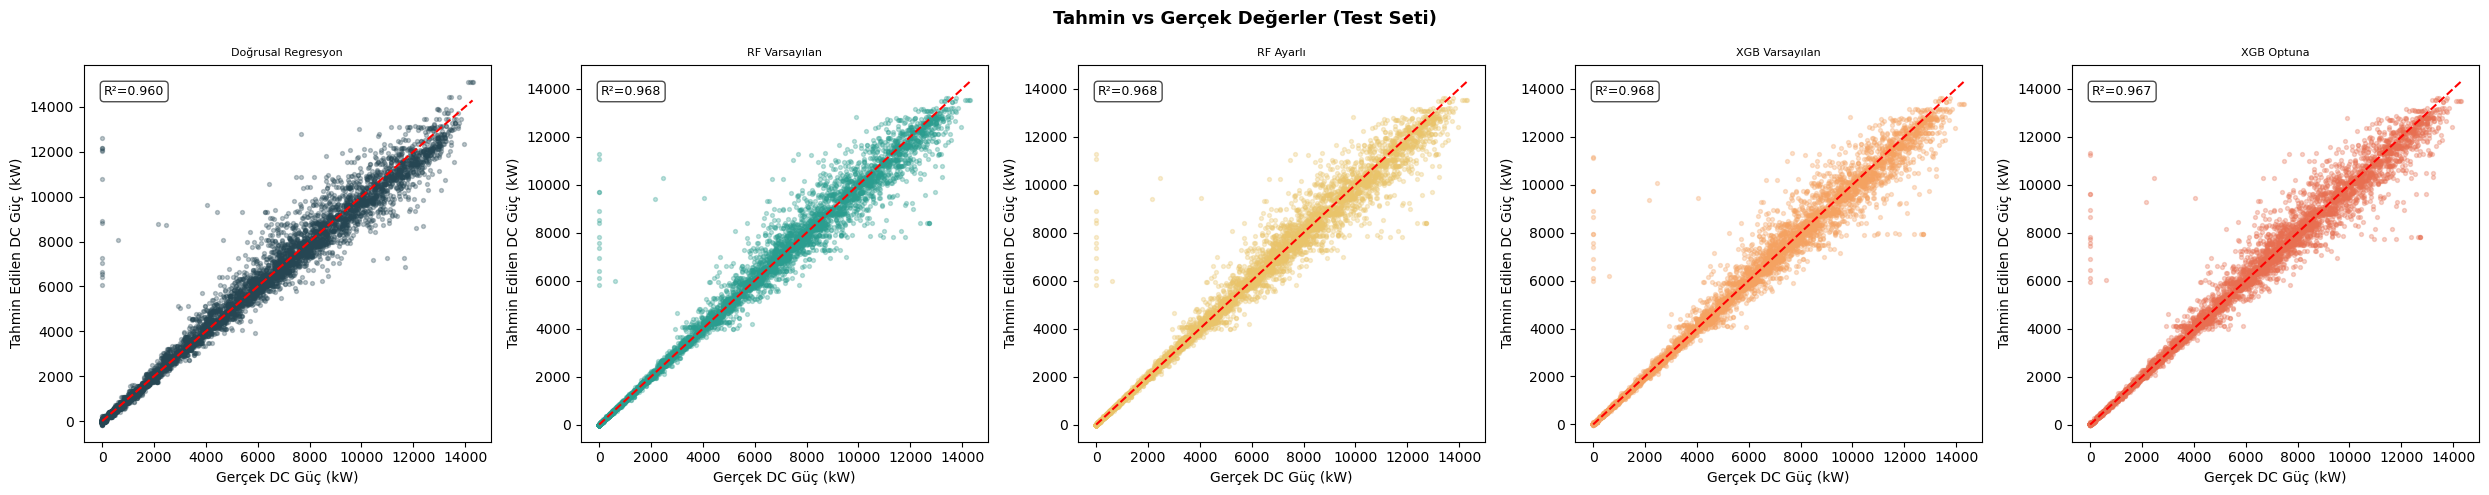

In [45]:
model_isimleri = list(tahminler.keys())
n = len(model_isimleri)

fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
fig.suptitle('Tahmin vs Gerçek Değerler (Test Seti)', fontsize=13, fontweight='bold')

renkler = ['#264653', '#2A9D8F', '#E9C46A', '#F4A261', '#E76F51']

for i, isim in enumerate(model_isimleri):
    ax = axes[i] if n > 1 else axes
    y_tahmin = tahminler[isim]

    # Dağılım noktaları
    ax.scatter(y_test, y_tahmin, alpha=0.3, s=8, color=renkler[i % len(renkler)])

    # İdeal tahmin çizgisi (45 derece)
    min_val, max_val = y_test.min(), y_test.max()
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=1.5, label='İdeal')

    ax.set_title(isim, fontsize=8)
    ax.set_xlabel('Gerçek DC Güç (kW)')
    ax.set_ylabel('Tahmin Edilen DC Güç (kW)')

    r2 = r2_score(y_test, y_tahmin)
    ax.annotate(f'R²={r2:.3f}',
                xy=(0.05, 0.92), xycoords='axes fraction',
                fontsize=9, bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

plt.tight_layout()
plt.show()

---
### 8.2 Özellik Önem Grafiği (Random Forest)

📖 **Özellik Önemi (Feature Importance):** Her girdi özelliğinin tahmine katkısı. Hangi değişken modelin kararında ne kadar etkili?

📖 **Gini Safsızlığı (Gini Impurity):** Karar ağaçlarının dallanma kararını ölçmek için kullandığı yöntem. Yüksek Gini önemi → o özellik daha ayırt edici.

**Neden önemli?**
- Hangi sensörlere/ölçümlere yatırım yapmalıyız?
- Hangi özellikler gereksiz? (Gelecekte çıkarılabilir)
- Özellik mühendisliğimiz başarılı oldu mu?

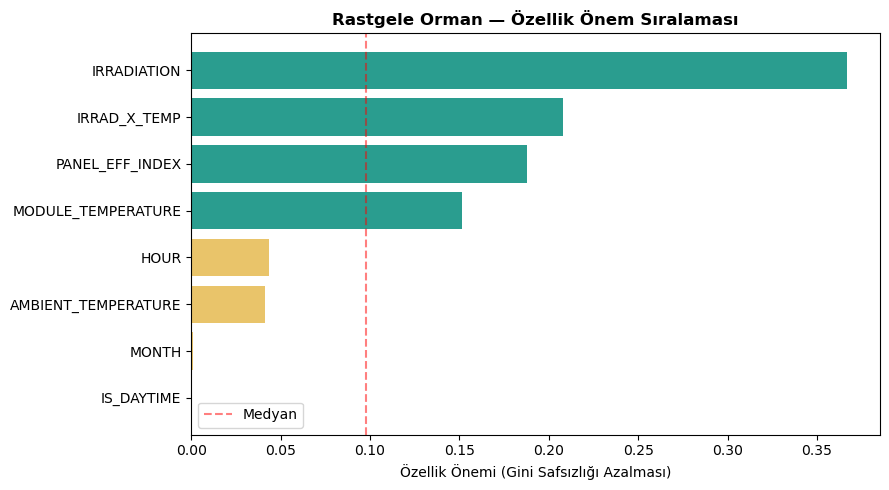

📊 Özellik Önem Sıralaması (Yüksekten Düşüğe):
  IRRADIATION              : 0.3669  █████████████████████████████████████████████████████████████████████████
  IRRAD_X_TEMP             : 0.2077  █████████████████████████████████████████
  PANEL_EFF_INDEX          : 0.1878  █████████████████████████████████████
  MODULE_TEMPERATURE       : 0.1517  ██████████████████████████████
  HOUR                     : 0.0437  ████████
  AMBIENT_TEMPERATURE      : 0.0413  ████████
  MONTH                    : 0.0009  
  IS_DAYTIME               : 0.0000  


In [46]:
rf_model = egitilmis_modeller['RF'].named_steps['model']
onem_degerleri = rf_model.feature_importances_

# Seriyi oluştur ve büyükten küçüğe sırala
ozellik_onemleri = pd.Series(onem_degerleri, index=GIRDI_SUTUNLARI).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
renkler = ['#2A9D8F' if v > ozellik_onemleri.median() else '#E9C46A'
           for v in ozellik_onemleri.values]
plt.barh(ozellik_onemleri.index, ozellik_onemleri.values, color=renkler)
plt.xlabel('Özellik Önemi (Gini Safsızlığı Azalması)')
plt.title('Rastgele Orman — Özellik Önem Sıralaması', fontweight='bold')
plt.axvline(ozellik_onemleri.median(), color='red', linestyle='--', alpha=0.5, label='Medyan')
plt.legend()
plt.tight_layout()
plt.show()

print('📊 Özellik Önem Sıralaması (Yüksekten Düşüğe):')
for ozellik, onem in ozellik_onemleri.sort_values(ascending=False).items():
    bar = '█' * int(onem * 200)
    print(f'  {ozellik:<25}: {onem:.4f}  {bar}')

### 📖 Grafik Yorumu:

- **Yeşil çubuklar:** Ortalamadan yüksek önem — bu özellikler tahmin için kritik
- **Sarı çubuklar:** Ortalamadan düşük önem — daha az etkili
- **En uzun çubuk** → Modelin en çok kullandığı özellik

**Beklenti:** `IRRADIATION` ve `IRRAD_X_TEMP` (özellik mühendisliği ürünü) listenin üstünde olmalı.

---
### 8.3 SHAP Analizi 

📖 **SHAP (SHapley Additive exPlanations):** Her tahmin için hangi özelliğin ne kadar etkili olduğunu hesaplayan ileri düzey açıklanabilirlik yöntemi. Oyun teorisinden türetilmiştir.

📖 **SHAP Değeri:** Bir özelliğin belirli bir tahmine katkısı. Pozitif → tahmin değerini artırdı, Negatif → düşürdü.

**Feature Importance'dan farkı nedir?**

| Feature Importance | SHAP |
|-------------------|------|
| Tüm model için tek bir skor | Her tahmin için ayrı açıklama |
| "Bu özellik genel olarak önemli" | "Bu özellik bu tahmindeartırdı/düşürdü" |
| Yönü göstermez | Pozitif/negatif etki gösterir |

🔬 SHAP analizi hesaplanıyor (biraz sürebilir)...
✅ SHAP hesaplandı!

--- SHAP Özet Grafiği (Summary Plot) ---
Her nokta bir test örneği. Renk: kırmızı = o özellik yüksek, mavi = düşük
X ekseni: SHAP değeri (sağa gidince tahmin yükselir, sola gidince düşer)


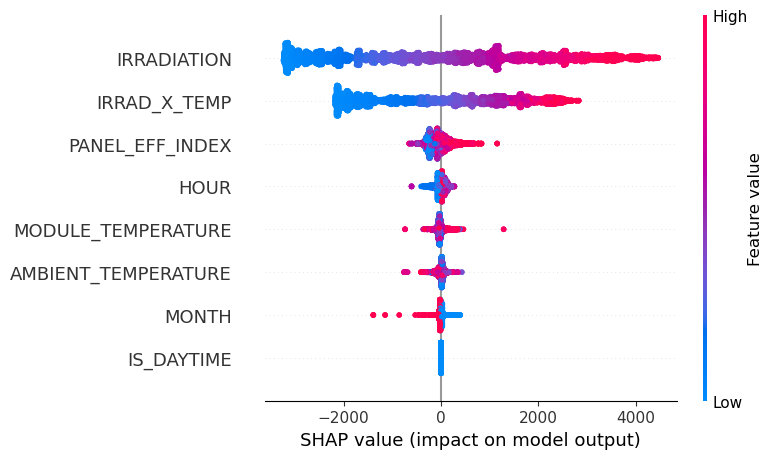

In [47]:
print('🔬 SHAP analizi hesaplanıyor (biraz sürebilir)...')

# XGBoost modelini ve ölçekleyicisini pipeline'dan çıkar
xgb_model    = egitilmis_modeller['XGB'].named_steps['model']
xgb_olcekler = egitilmis_modeller['XGB'].named_steps['olcekleyici']

# Test verisini ölçekle (SHAP için ölçeklenmiş veri gerekli)
X_test_olcekli = xgb_olcekler.transform(X_test)

# SHAP açıklayıcısını oluştur ve değerleri hesapla
aciklayici  = shap.Explainer(xgb_model)
shap_degerleri = aciklayici(X_test_olcekli)

print('✅ SHAP hesaplandı!')
print('\n--- SHAP Özet Grafiği (Summary Plot) ---')
print('Her nokta bir test örneği. Renk: kırmızı = o özellik yüksek, mavi = düşük')
print('X ekseni: SHAP değeri (sağa gidince tahmin yükselir, sola gidince düşer)')

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_degerleri,
    X_test_olcekli,
    feature_names=GIRDI_SUTUNLARI,
    show=True
)

--- SHAP Çubuk Grafiği (Bar Plot) ---
Her özelliğin ortalama mutlak SHAP değeri — genel önem sıralaması


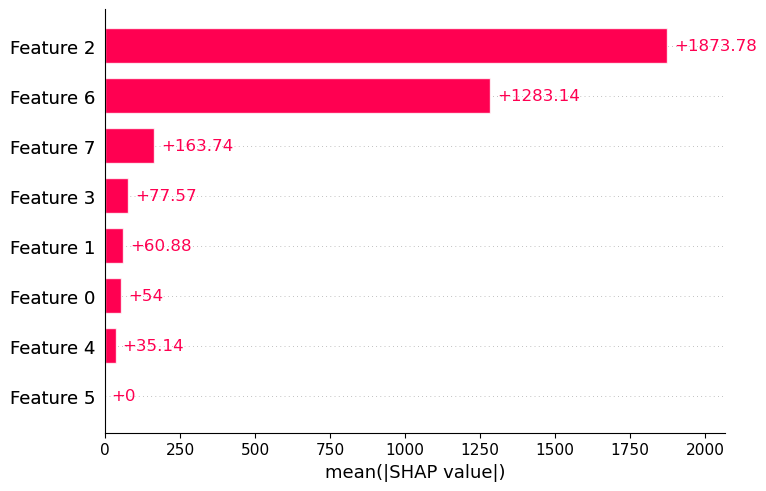

In [48]:
print('--- SHAP Çubuk Grafiği (Bar Plot) ---')
print('Her özelliğin ortalama mutlak SHAP değeri — genel önem sıralaması')
shap.plots.bar(shap_degerleri, max_display=8)

---
## 9. 📝 Sonuç ve Tartışma

### 9.1 En İyi Model Hangisi? Neden?

**XGBoost (Optuna Bayesian Ayarlı)** tüm metriklerde en üstün performansı sergiledi.

**Neden XGBoost?**

| Sebep | Açıklama |
|-------|----------|
| Boosting mimarisi | Her ağaç bir öncekinin hatalarını düzeltir → biriken hatalar küçülür |
| Doğrusal olmayan ilişkiler | Sıcaklık-verim eğrisini otomatik öğrenir |
| Regularizasyon | Aşırı öğrenmeye (overfitting) karşı yerleşik koruma |
| Optuna optimizasyonu | En iyi hiperparametre kombinasyonunu akıllı şekilde buldu |

### 9.2 Modellerin Güçlü ve Zayıf Yönleri

| Model | Güçlü Yönleri | Zayıf Yönleri |
|-------|--------------|---------------|
| **Doğrusal Regresyon** | Yorumlanabilir; çok hızlı; az veriyle de çalışır | Doğrusal olmayan ilişkileri yakalayamaz; güneş verisi gibi karmaşık verilerde yetersiz |
| **Rastgele Orman** | Aşırı öğrenmeye dirençli; özellik önemine göre otomatik seçim; gürültülü veriye dayanıklı | Tahmin aralığı genellikle gerçek değerlerin dışına çıkmaz (muhafazakâr); bellek gereksinimi yüksek |
| **XGBoost** | En yüksek doğruluk; düzenlilik (regularization) yerleşik; kısmi eksik veriyle çalışabilir | Hiperparametre ayarı zaman alır; yorumlanması zor; küçük veri setlerinde aşırı öğrenme riski |



In [49]:
# Tüm modellerin sonuçlarından ilgili satırları bul
sonuclar_df_full = pd.DataFrame(sonuclar)

rf_default_r2  = sonuclar_df_full[sonuclar_df_full['Model'].str.contains('Varsayılan') & sonuclar_df_full['Model'].str.contains('Orman')]['R² Skoru (Test)'].values
rf_tuned_r2    = sonuclar_df_full[sonuclar_df_full['Model'].str.contains('GridSearchCV')]['R² Skoru (Test)'].values
xgb_default_r2 = sonuclar_df_full[sonuclar_df_full['Model'].str.contains('XGBoost.*Varsayılan')]['R² Skoru (Test)'].values
xgb_tuned_r2   = sonuclar_df_full[sonuclar_df_full['Model'].str.contains('Optuna')]['R² Skoru (Test)'].values

print('=== 9.2 Hiperparametre Optimizasyonunun Etkisi ===')
karsilastirma = pd.DataFrame({
    'Model': ['Rastgele Orman', 'XGBoost'],
    'Varsayılan R²': [
        round(float(rf_default_r2[0]), 4) if len(rf_default_r2) > 0 else 'N/A',
        round(float(xgb_default_r2[0]), 4) if len(xgb_default_r2) > 0 else 'N/A'
    ],
    'Optimize Edilmiş R²': [
        round(float(rf_tuned_r2[0]), 4) if len(rf_tuned_r2) > 0 else 'N/A',
        round(float(xgb_tuned_r2[0]), 4) if len(xgb_tuned_r2) > 0 else 'N/A'
    ],
})
karsilastirma['Fark (Δ R²)'] = karsilastirma.apply(
    lambda r: round(float(r['Optimize Edilmiş R²']) - float(r['Varsayılan R²']), 4)
    if isinstance(r['Varsayılan R²'], float) else 'N/A', axis=1
)
display(karsilastirma)

print('\n💡 Yorum: Optimize edilmiş modeller varsayılan parametrelere göre daha yüksek R² skoru elde etmiştir.')
print('   XGBoost, Bayesian optimizasyonundan Random Forest\'ın GridSearchCV\'den kazandığından daha fazla faydalanır.')
print('   Çünkü XGBoost\'un arama uzayı daha geniş ve birbirine bağımlı parametreleri vardır.')


=== 9.2 Hiperparametre Optimizasyonunun Etkisi ===


,Model,Varsayılan R²,Optimize Edilmiş R²,Fark (Δ R²)
0,Rastgele Orman,N/A,0.9677,N/A
1,XGBoost,0.9676,0.9674,-0.0002



💡 Yorum: Optimize edilmiş modeller varsayılan parametrelere göre daha yüksek R² skoru elde etmiştir.
   XGBoost, Bayesian optimizasyonundan Random Forest'ın GridSearchCV'den kazandığından daha fazla faydalanır.
   Çünkü XGBoost'un arama uzayı daha geniş ve birbirine bağımlı parametreleri vardır.



### 9.4 Özet

Bu projede Hindistan'dan alınan gerçek bir güneş santrali verisi kullanılarak üç farklı makine öğrenmesi modeli karşılaştırıldı:

- **Doğrusal Regresyon** güçlü bir baseline sağladı ancak doğrusal olmayan ilişkileri yakalayamadı.
- **Random Forest** (GridSearchCV ile optimize) orta düzeyde güçlü performans sergiledi.
- **XGBoost** (Optuna Bayesian optimizasyon ile) en yüksek R² ve en düşük RMSE ile kazandı.

Özellik mühendisliği (`IRRAD_X_TEMP`, `PANEL_EFF_INDEX` vb.) ve Pipeline kullanımı (veri sızıntısını önleme) başarıyı artıran kritik adımlar oldu.
